# **Lab 4.3. Шаврин Алексей, группа 1306**

# Импорты

In [55]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

np.random.seed(42)

# Загрузка исходных данных

In [3]:
iris = load_iris()
X, y = iris.data, iris.target

# Разделение на обучающую и тестовую выборки

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((112, 4), (38, 4), (112,), (38,))

# Масштабирование признаков

In [44]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Функция создания нейронной сети

In [45]:
def create_model(hidden_units):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(4,)))
    for units in hidden_units:
        model.add(tf.keras.layers.Dense(units, activation='relu'))
    model.add(tf.keras.layers.Dense(3, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Обучение моделей

In [58]:
# Большая модель
model_1 = create_model([1024, 512, 256])
history_1 = model_1.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)
loss_1, accuracy_1 = model_1.evaluate(X_test, y_test, verbose=0)
print("Точность на тестовой выборке:", accuracy_1)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 183ms/step - accuracy: 0.7528 - loss: 0.7023 - val_accuracy: 0.7826 - val_loss: 0.5033
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.8427 - loss: 0.2929 - val_accuracy: 0.7826 - val_loss: 0.4925
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9213 - loss: 0.1724 - val_accuracy: 0.8696 - val_loss: 0.4773
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9551 - loss: 0.1141 - val_accuracy: 0.8696 - val_loss: 0.5056
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.9551 - loss: 0.0844 - val_accuracy: 0.9130 - val_loss: 0.6229
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.9775 - loss: 0.0639 - val_accuracy: 0.8696 - val_loss: 0.6202
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9438 - loss: 0.0727 - val_accuracy: 0.8696 - val_loss: 0.9577
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9101 - loss: 0.1285 - val_accuracy: 0.8696 - val_loss: 0.6272

In [65]:
# Малая модель
model_2 = create_model([300, 100])
history_2 = model_2.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)
loss_2, accuracy_2 = model_2.evaluate(X_test, y_test, verbose=0)
print("Точность на тестовой выборке:", accuracy_2)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.6629 - loss: 0.9006 - val_accuracy: 0.7391 - val_loss: 0.7617
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8539 - loss: 0.6093 - val_accuracy: 0.7391 - val_loss: 0.6055
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8652 - loss: 0.4577 - val_accuracy: 0.7826 - val_loss: 0.5177
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8764 - loss: 0.3688 - val_accuracy: 0.7391 - val_loss: 0.4690
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8764 - loss: 0.3116 - val_accuracy: 0.7391 - val_loss: 0.4457
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8876 - loss: 0.2698 - val_accuracy: 0.7826 - val_loss: 0.4369
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8876 - loss: 0.2419 - val_accuracy: 0.7826 - val_loss: 0.4338
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9101 - loss: 0.2143 - val_accuracy: 0.7826 - val_loss: 0.4299


# Отчеты по классификации

In [66]:
# Большая модель
y_pred_1 = model_1.predict(X_test)
y_pred_1_classes = np.argmax(y_pred_1, axis=1)
print(classification_report(y_test, y_pred_1_classes, target_names=iris.target_names))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
              precision    recall  f1-score   support

      setosa       1.00      0.92      0.96        12
  versicolor       0.77      0.77      0.77        13
   virginica       0.79      0.85      0.81        13

    accuracy                           0.84        38
   macro avg       0.85      0.84      0.85        38
weighted avg       0.85      0.84      0.84        38



In [67]:
# Малая модель
y_pred_2 = model_2.predict(X_test)
y_pred_2_classes = np.argmax(y_pred_2, axis=1)
print(classification_report(y_test, y_pred_2_classes, target_names=iris.target_names))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
              precision    recall  f1-score   support

      setosa       1.00      0.92      0.96        12
  versicolor       0.79      0.85      0.81        13
   virginica       0.85      0.85      0.85        13

    accuracy                           0.87        38
   macro avg       0.88      0.87      0.87        38
weighted avg       0.87      0.87      0.87        38



# Сравнение моделей

In [68]:
print("Точность модели [1024, 512, 256]:", accuracy_1)
print("Точность модели [300, 100]:", accuracy_2)

if accuracy_1 > accuracy_2:
    print("Лучшую точность показала модель [1024, 512, 256]")
elif accuracy_2 > accuracy_1:
    print("Лучшую точность показала модель [300, 100]")
else:
    print("Обе модели показали одинаковую точность")

Точность модели [1024, 512, 256]: 0.8421052694320679
Точность модели [300, 100]: 0.8684210777282715
Лучшую точность показала модель [300, 100]


# Визуализация процессов обучения

In [69]:
def plot_training_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # График потерь (loss)
    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # График точности (accuracy)
    axes[1].plot(history.history['accuracy'], label='Train Accuracy')
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

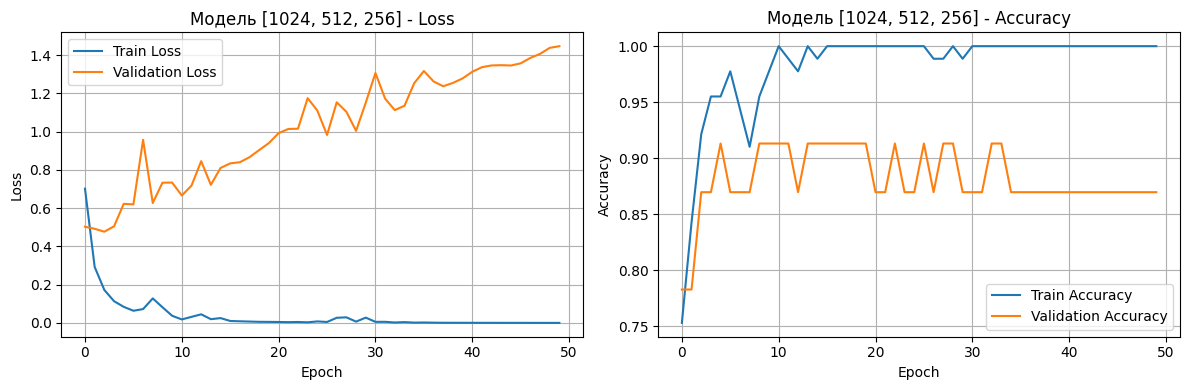

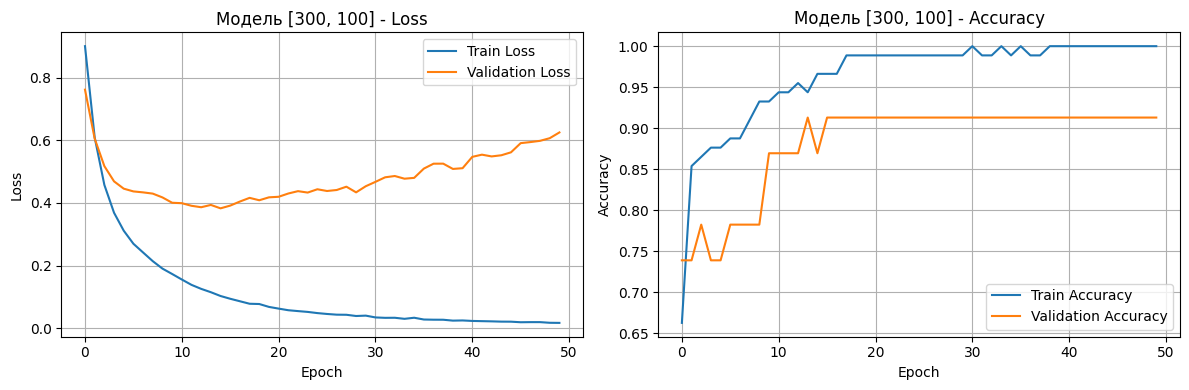

In [70]:
plot_training_history(history_1, "Модель [1024, 512, 256]")
plot_training_history(history_2, "Модель [300, 100]")